In [ ]:
# import package & download dataset from kaggle lgsg
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

print("TensorFlow:", tf.__version__)

# download otomatis from kagglehub
download_path = kagglehub.dataset_download("leftin/fruit-ripeness-unripe-ripe-and-rotten")

# arahkan root_dataset langsung ke folder hasil download yang isinya train & test
root_dataset = None
for root, dirs, files in os.walk(download_path):
    if "train" in dirs and "test" in dirs:
        root_dataset = root
        break

train_original = os.path.join(root_dataset, "train")
test_original = os.path.join(root_dataset, "test")

processed_root = "processed_dataset"

# liat otomatis struktur foldernya (ripe, unripe, rotten)
if os.path.exists(processed_root):
    shutil.rmtree(processed_root)

os.makedirs(processed_root)

for split in ["train", "test"]:

    os.makedirs(
        os.path.join(processed_root, split, "ripe"),
        exist_ok=True
    )

    os.makedirs(
        os.path.join(processed_root, split, "rotten"),
        exist_ok=True
    )

    os.makedirs(
        os.path.join(processed_root, split, "unripe"),
        exist_ok=True
    )

TensorFlow: 2.20.0


100%|██████████| 3.63G/3.63G [00:29<00:00, 131MB/s]

Extracting files...


In [ ]:
import tensorflow as tf

print(tf.__version__)

2.20.0


In [ ]:
print("root_dataset =", root_dataset)
print("train_original =", train_original)
print("test_original =", test_original)

print("root ada?", os.path.exists(root_dataset))
print("train ada?", os.path.exists(train_original))
print("test ada?", os.path.exists(test_original))

root_dataset = /root/.cache/kagglehub/datasets/leftin/fruit-ripeness-unripe-ripe-and-rotten/versions/2/fruit_ripeness_dataset/archive (1)/dataset
train_original = /root/.cache/kagglehub/datasets/leftin/fruit-ripeness-unripe-ripe-and-rotten/versions/2/fruit_ripeness_dataset/archive (1)/dataset/train
test_original = /root/.cache/kagglehub/datasets/leftin/fruit-ripeness-unripe-ripe-and-rotten/versions/2/fruit_ripeness_dataset/archive (1)/dataset/test
root ada? True
train ada? True
test ada? True


In [ ]:
def merge_classes(source_dir, destination_dir):

    for folder in os.listdir(source_dir):

        source_folder = os.path.join(source_dir, folder)

        if not os.path.isdir(source_folder):
            continue

        folder_lower = folder.lower()

        if "fresh" in folder_lower:
            target = "ripe"

        elif "rotten" in folder_lower:
            target = "rotten"

        elif "unripe" in folder_lower:
            target = "unripe"

        else:
            continue

        target_folder = os.path.join(
            destination_dir,
            target
        )

        for file in os.listdir(source_folder):

            src = os.path.join(
                source_folder,
                file
            )

            dst = os.path.join(
                target_folder,
                f"{folder}_{file}"
            )

            shutil.copy2(src, dst)

merge_classes(
    train_original,
    os.path.join(processed_root, "train")
)

merge_classes(
    test_original,
    os.path.join(processed_root, "test")
)

print("Dataset berhasil diubah menjadi 3 kelas")

Dataset berhasil diubah menjadi 3 kelas


In [ ]:
# data preprocessing sama cleaning data
IMG_SIZE = (150, 150) #size gambar disamain semua
BATCH_SIZE = 32

train_dir = os.path.join(
    processed_root,
    "train"
)

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print(class_names)

Found 16217 files belonging to 3 classes.
Using 12974 files for training.
Found 16217 files belonging to 3 classes.
Using 3243 files for validation.
['ripe', 'rotten', 'unripe']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

# augmentation
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(
        height_factor=0.2,
        width_factor=0.2
    )
])

# modelling (mobilenetv2)
print("\n--- Arsitektur MobileNetV2 ---")

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(150,150,3)
)

base_model.trainable = False

inputs = layers.Input(shape=(150,150,3))

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = Model(
    inputs,
    outputs
)

model.summary()


--- Arsitektur MobileNetV2 ---


/tmp/ipykernel_1196/706126985.py:21: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# kompilasi epoch dan training model
print("\n--- Kompilasi dan Training Model ---")
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_list = [

    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=0.00001,
        verbose=1
    )
]

EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_list
)

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Memulai Tahap Fine-Tuning ---")
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10, # epoch yg utk fine tuning
    callbacks=callbacks_list
)


--- Kompilasi dan Training Model ---
Epoch 1/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 66s 65ms/step - accuracy: 0.6154 - loss: 0.9436 - val_accuracy: 0.8757 - val_loss: 0.3303 - learning_rate: 1.0000e-04
Epoch 2/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.8395 - loss: 0.4090 - val_accuracy: 0.9278 - val_loss: 0.2124 - learning_rate: 1.0000e-04
Epoch 3/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0.8830 - loss: 0.3038 - val_accuracy: 0.9408 - val_loss: 0.1701 - learning_rate: 1.0000e-04
Epoch 4/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.9067 - loss: 0.2491 - val_accuracy: 0.9439 - val_loss: 0.1544 - learning_rate: 1.0000e-04
Epoch 5/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.9128 - loss: 0.2269 - val_accuracy: 0.9528 - val_loss: 0.1364 - learning_rate: 1.0000e-04
Epoch 6/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.9208 - loss: 0.2081 - val_accuracy: 0.9507 - val_loss: 0.1361 - learning_rate: 1.0000e-04
Epoch 7/15
406


--- Visualisasi Performa Model ---


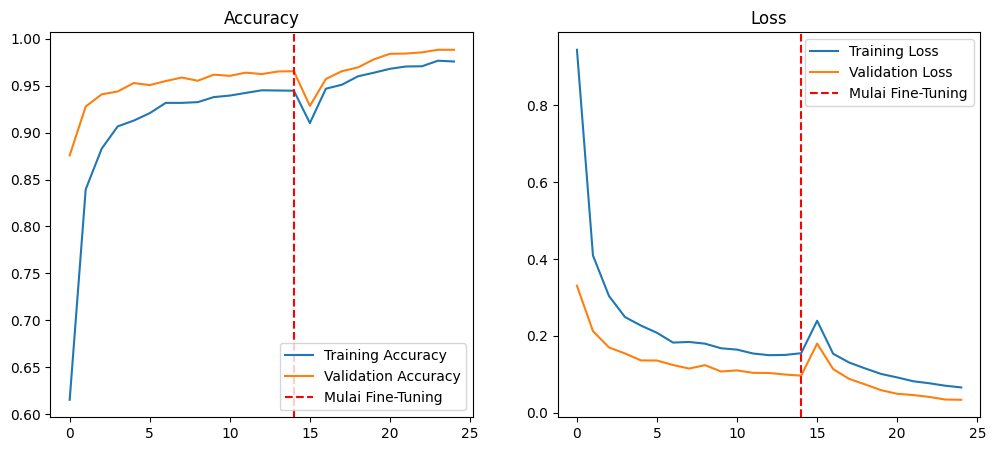

In [ ]:
# evaluasi dan visualiasi hasil training
print("\n--- Visualisasi Performa Model ---")

acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.axvline(x=len(history.history['accuracy'])-1, color='r', linestyle='--', label='Mulai Fine-Tuning')
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(x=len(history.history['loss'])-1, color='r', linestyle='--', label='Mulai Fine-Tuning')
plt.title("Loss")
plt.legend()

plt.show()

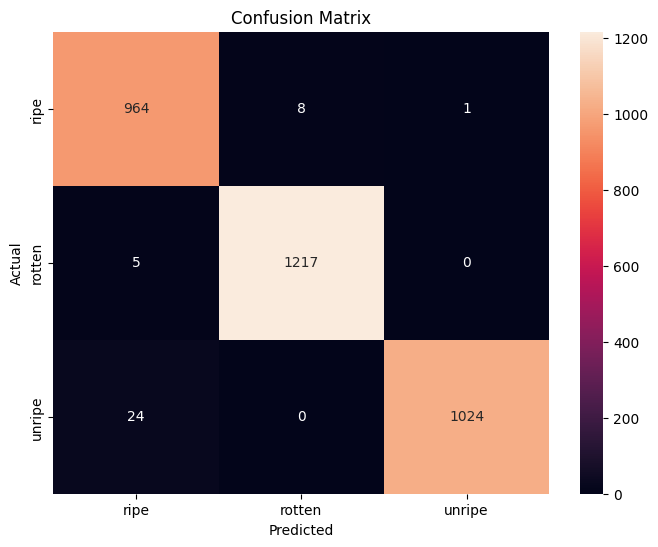

              precision    recall  f1-score   support

        ripe       0.97      0.99      0.98       973
      rotten       0.99      1.00      0.99      1222
      unripe       1.00      0.98      0.99      1048

    accuracy                           0.99      3243
   macro avg       0.99      0.99      0.99      3243
weighted avg       0.99      0.99      0.99      3243



In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:

    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

In [ ]:
model.save(
    "model_klasifikasi_buah_final_v2.keras"
)

print(
    "Model berhasil disimpan"
)

Model berhasil disimpan
